<a href="https://colab.research.google.com/github/ssssssshy/project/blob/main/BadModel(lung_disease_data).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

In [2]:
df = pd.read_csv('lung_disease_data.csv')

In [3]:
df.head()

,Age,Gender,Smoking Status,Lung Capacity,Disease Type,Treatment Type,Hospital Visits,Recovered
0,71.0,Female,No,4.49,COPD,Therapy,14.0,Yes
1,34.0,Female,Yes,NaN,Bronchitis,Surgery,7.0,No
2,80.0,Male,Yes,1.95,COPD,NaN,4.0,Yes
3,40.0,Female,Yes,NaN,Bronchitis,Medication,1.0,No
4,43.0,Male,Yes,4.60,COPD,Surgery,NaN,Yes


🧑‍🤝‍🧑 Age & Gender: Patient demographics to understand the spread across age groups and gender.

🚬 Smoking Status: Whether the patient is a smoker or non-smoker.

🌡️ Lung Capacity: Measured lung function to assess disease severity.

🫁 Disease Type: The specific lung condition, like COPD or Bronchitis.

💊 Treatment Type: Different treatments patients received, including therapy, medication, or surgery.

🏥 Hospital Visits: Number of visits to the hospital for managing the condition.

✅ Recovery Status: Indicates whether the patient recovered after treatment.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              4900 non-null   float64
 1   Gender           4900 non-null   object 
 2   Smoking Status   4900 non-null   object 
 3   Lung Capacity    4900 non-null   float64
 4   Disease Type     4900 non-null   object 
 5   Treatment Type   4900 non-null   object 
 6   Hospital Visits  4900 non-null   float64
 7   Recovered        4900 non-null   object 
dtypes: float64(3), object(5)
memory usage: 325.1+ KB


In [5]:
df.describe()

,Age,Lung Capacity,Hospital Visits
count,4900.000000,4900.000000,4900.000000
mean,54.449796,3.501865,7.528571
std,20.126882,1.461179,3.996401
min,20.000000,1.000000,1.000000
25%,37.000000,2.220000,4.000000
50%,54.000000,3.480000,8.000000
75%,72.000000,4.800000,11.000000
max,89.000000,6.000000,14.000000


In [8]:
df.isnull().sum()

,0
Age,300
Gender,300
Smoking Status,300
Lung Capacity,300
Disease Type,300
Treatment Type,300
Hospital Visits,300
Recovered,300


<Axes: >

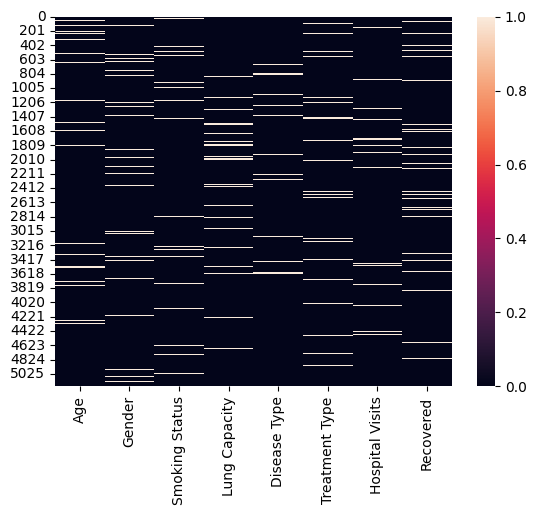

In [12]:
sns.heatmap(df.isnull())

In [13]:
df.head()

,Age,Gender,Smoking Status,Lung Capacity,Disease Type,Treatment Type,Hospital Visits,Recovered
0,71.0,Female,No,4.49,COPD,Therapy,14.0,Yes
1,34.0,Female,Yes,NaN,Bronchitis,Surgery,7.0,No
2,80.0,Male,Yes,1.95,COPD,NaN,4.0,Yes
3,40.0,Female,Yes,NaN,Bronchitis,Medication,1.0,No
4,43.0,Male,Yes,4.60,COPD,Surgery,NaN,Yes


In [19]:
numerical = ['Age','Lung Capacity','Hospital Visits']
categorical = ['Gender','Smoking Status','Disease Type','Treatment Type','Recovered']

imputer = KNNImputer(n_neighbors=3)
df[numerical] = imputer.fit_transform(df[numerical])

for cat in categorical:
  if df[cat].isnull().sum() > 0:
    df[cat].fillna(df[cat].mode()[0], inplace= True)
    print(f'Заполнили недостающие значения в {cat} наиболее часто встречаемым {df[cat].mode()[0]}')

Заполнили недостающие значения в Recovered наиболее часто встречаемым Yes


<ipython-input-19-b2be4f80f910>:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[cat].fillna(df[cat].mode()[0], inplace= True)


In [20]:
df.isnull().sum()

,0
Age,0
Gender,0
Smoking Status,0
Lung Capacity,0
Disease Type,0
Treatment Type,0
Hospital Visits,0
Recovered,0


In [21]:
df.head()

,Age,Gender,Smoking Status,Lung Capacity,Disease Type,Treatment Type,Hospital Visits,Recovered
0,71.0,Female,No,4.490000,COPD,Therapy,14.0,Yes
1,34.0,Female,Yes,2.350000,Bronchitis,Surgery,7.0,No
2,80.0,Male,Yes,1.950000,COPD,Medication,4.0,Yes
3,40.0,Female,Yes,5.243333,Bronchitis,Medication,1.0,No
4,43.0,Male,Yes,4.600000,COPD,Surgery,11.0,Yes


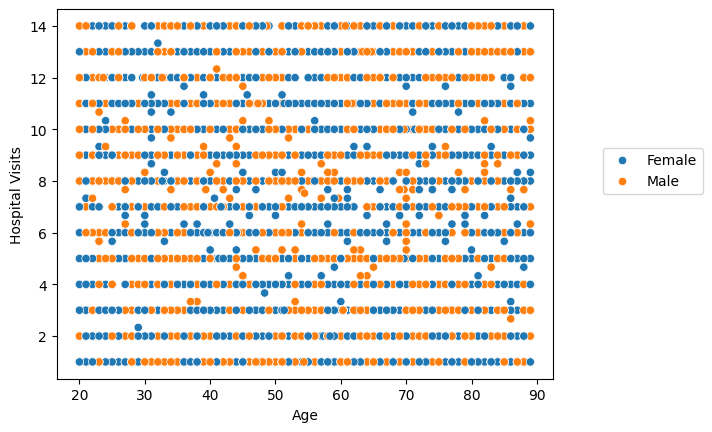

In [24]:
sns.scatterplot(data = df, x='Age',y='Hospital Visits',hue = 'Gender')
plt.legend(loc=(1.1,0.5))

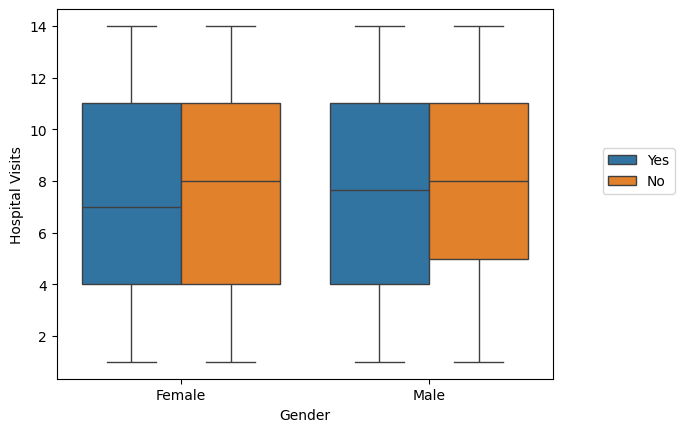

In [32]:
sns.boxplot(data = df, x='Gender',y='Hospital Visits',hue = 'Recovered')
plt.legend(loc=(1.1,0.5))

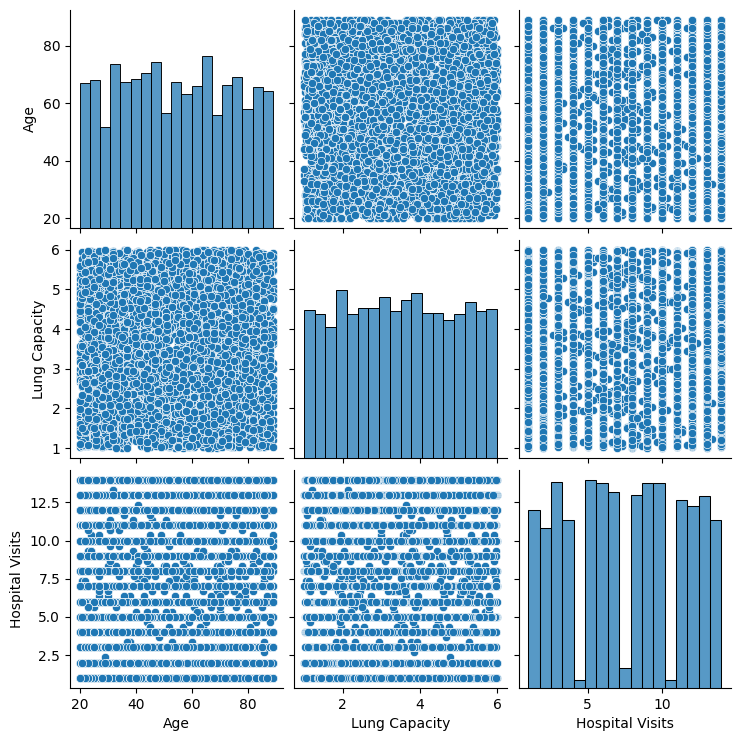

In [33]:
sns.pairplot(df)

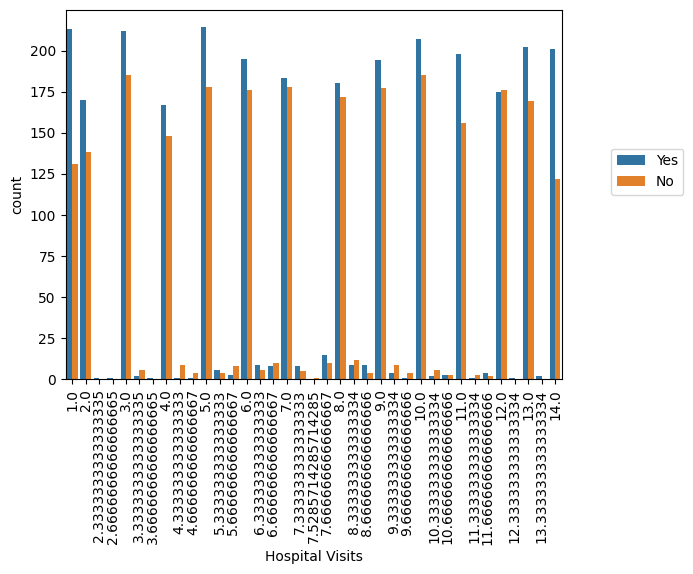

In [44]:
sns.countplot(data = df, x='Hospital Visits',hue='Smoking Status')
plt.xticks(rotation = 90);
plt.legend(loc=(1.1,0.5))

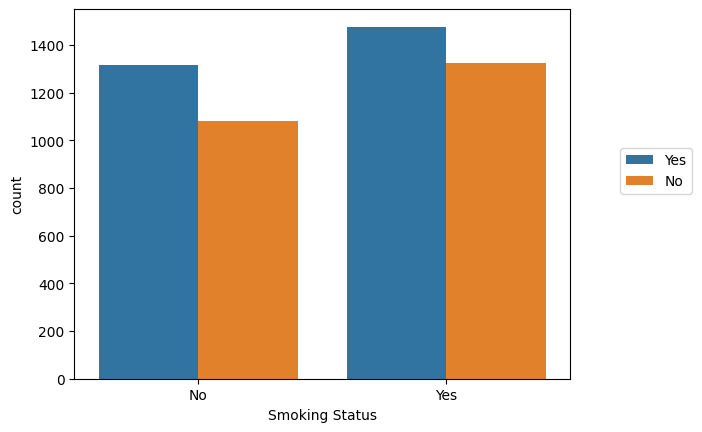

In [54]:
sns.countplot(data = df,x='Smoking Status', hue = 'Recovered')
plt.legend(loc=(1.1,0.5))

In [55]:
df.head()

,Age,Gender,Smoking Status,Lung Capacity,Disease Type,Treatment Type,Hospital Visits,Recovered
0,71.0,Female,No,4.490000,COPD,Therapy,14.0,Yes
1,34.0,Female,Yes,2.350000,Bronchitis,Surgery,7.0,No
2,80.0,Male,Yes,1.950000,COPD,Medication,4.0,Yes
3,40.0,Female,Yes,5.243333,Bronchitis,Medication,1.0,No
4,43.0,Male,Yes,4.600000,COPD,Surgery,11.0,Yes


In [64]:
lablen = LabelEncoder()
df['Recovered'] = lablen.fit_transform(df['Recovered'])

In [65]:
X = pd.get_dummies(df.drop('Recovered',axis=1), drop_first= True)
y = df['Recovered']

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [71]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [77]:
model_xgb = XGBClassifier()
param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search_xgb = GridSearchCV(estimator=model_xgb, param_grid=param_grid_xgb,
                               scoring='accuracy', cv=5, n_jobs=-1)

grid_search_xgb.fit(X_train, y_train)

print("Лучшие параметры для XGBClassifier:", grid_search_xgb.best_params_)


print("Лучшая точность:", grid_search_xgb.best_score_)

Лучшие параметры для XGBClassifier: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 50, 'subsample': 0.8}
Лучшая точность: 0.5406593406593406


In [78]:
model_dt = DecisionTreeClassifier()
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_search_dt = GridSearchCV(estimator=model_dt, param_grid=param_grid_dt,
                              scoring='accuracy', cv=5, n_jobs=-1)

grid_search_dt.fit(X_train, y_train)

print("Лучшие параметры для DecisionTreeClassifier:",
      grid_search_dt.best_params_)

print("Лучшая точность:", grid_search_dt.best_score_)

Лучшие параметры для DecisionTreeClassifier: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2}
Лучшая точность: 0.5343406593406593


In [82]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Предсказания для DecisionTree
y_pred_dt = grid_search_dt.predict(X_test)

# Предсказания для XGBoost
y_pred_xgb = grid_search_xgb.predict(X_test)
print("DecisionTreeClassifier:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt)}")
print(f"Precision: {precision_score(y_test, y_pred_dt)}")
print(f"Recall: {recall_score(y_test, y_pred_dt)}")
print(f"F1-Score: {f1_score(y_test, y_pred_dt)}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_dt)}")

# Оценка XGBoost
print("\nXGBClassifier:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb)}")
print(f"Precision: {precision_score(y_test, y_pred_xgb)}")
print(f"Recall: {recall_score(y_test, y_pred_xgb)}")
print(f"F1-Score: {f1_score(y_test, y_pred_xgb)}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_xgb)}")

DecisionTreeClassifier:
Accuracy: 0.5147435897435897
Precision: 0.5271779597915115
Recall: 0.8530120481927711
F1-Score: 0.6516336861481823
ROC-AUC: 0.49157451724707046

XGBClassifier:
Accuracy: 0.5237179487179487
Precision: 0.5286372613561554
Recall: 0.9674698795180723
F1-Score: 0.6836951894423159
ROC-AUC: 0.49332398085492657
